# Subtype classification with embedding-space SMOTE (coverage experiment)

`model_crnn_hierarchical.ipynb` reported an honest, LOSO-evaluated result: the subtype head
gets **0% recall on both minority classes** (`focal_aware`, `focal_to_bilateral_tonic_clonic`),
and synthetic oversampling cannot fix that under strict leave-one-subject-out — when the one
patient who carries a class is the held-out test patient, that fold's training set has
**zero** real examples of their class to synthesize from. SMOTE interpolates between existing
examples; it cannot invent a class's signature from patients who don't have it.

**This notebook makes a different, deliberate tradeoff, at the user's explicit request:**
relax patient-level LOSO to an **event-level stratified split** — every class gets real
windows in *both* train and test, from the *same* patient in both splits, so synthesis has
real material to work with and so recall on the minority classes can be measured at all. That
tradeoff has a real cost, stated plainly rather than buried: because `focal_aware` is only
ever `PN14` and `focal_to_bilateral_tonic_clonic` is only ever `PN10`, any accuracy this
notebook reports on those two classes may be partly (or mostly) recognising *that patient's*
EEG signature rather than the subtype itself — precisely the confound
`model_stage2_cnn1d_subtype.ipynb`'s adversarial control was built to catch. The same control
is run here, on the same protocol, so that confound is measured rather than assumed away.

**The classification task itself is unchanged**: detect seizure vs. non-seizure, then, if
seizure, classify which of the three ILAE subtypes. This notebook only replaces *how Phase B
(subtype) is trained and evaluated* — Phase A (detection) is reused verbatim from
`model_crnn_hierarchical.ipynb`'s checkpoint, unmodified.

## Design

1. **Reuse Phase A's backbone**, frozen. It's already the weight-transfer artifact from both
   datasets pooled — nothing about the detection stage changes here.
2. **Event-level stratified split** of Siena's subtype windows (not patient-level): each
   class's events are split so both train and test get real windows of every class, allocated
   by window count so a `focal_aware` event with 800 overlapping windows doesn't silently
   dominate the split the way a single big event could.
3. **Embedding-space SMOTE, not raw-signal SMOTE.** Interpolating between two raw 18-channel
   EEG windows produces a signal that isn't obviously a plausible in-between seizure --
   feature-space interpolation, downstream of the CRNN backbone's learned representation, is
   the standard fix for exactly this (deep-SMOTE / embedding SMOTE). The frozen backbone turns
   every window into a 128-d vector; SMOTE synthesizes new minority-class vectors from real
   ones in that space; a fresh classifier head trains on real + synthetic vectors together.
4. **A fresh subtype head**, not the LOSO one — trained purely on (real + synthetic)
   embeddings, since the embeddings themselves are static once the backbone is frozen.
5. **Adversarial control**, identical protocol, on interictal windows relabelled with each
   patient's own subtype -- the same sanity check Stage 2 and Phase B used, run here because
   this protocol is *more* exposed to the patient-recognition confound, not less.

## Config

In [1]:
import json
import warnings
from pathlib import Path

import h5py
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from imblearn.over_sampling import SMOTE
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from torch.utils.data import DataLoader, Dataset

warnings.filterwarnings("ignore")
plt.rcParams["figure.facecolor"] = "white"

# ---- paths --------------------------------------------------------------------------
WIN_ROOT = Path("../data/harmonized/windows")
PHASE_A_CKPT = Path("../checkpoints/crnn_hierarchical/phase_a_backbone_detector.pt")
CKPT_DIR = Path("../checkpoints/crnn_hierarchical_synthesis")
CKPT_DIR.mkdir(parents=True, exist_ok=True)

SEED = 20260803

# ---- split ------------------------------------------------------------------------------
TEST_FRAC = 0.3                      # per-class, allocated by window count, not event count
CONTROL_WINDOWS_PER_PATIENT = 150    # matches Stage 2 / Phase B's adversarial control size

# ---- backbone (must match model_crnn_hierarchical.ipynb's Phase A exactly) ----------------
CNN_WIDTH = 32
RNN_HIDDEN = 64
RNN_LAYERS = 1
CNN_DROPOUT = 0.1
RNN_DROPOUT = 0.2
PHASE_A_HEAD_DROPOUT = 0.35          # only used to instantiate the checkpoint's shape; unused after

# ---- SMOTE --------------------------------------------------------------------------------
# Full 'auto' balancing (minority -> majority count) would mean ~38x oversampling for
# focal_aware from ~30 real training points -- SMOTE would still run, but that many synthetic
# points drawn from so few real ones mostly densifies a small region rather than adding real
# diversity. Capping the oversample ratio keeps the synthetic:real balance defensible.
#
# MAX_OVERSAMPLE_RATIO=8 was tried first and capped at the majority count -- it pushed the
# training distribution to near 3-way parity (322/322/232 windows). Test accuracy collapsed to
# 0.12: a classifier trained on an artificially flattened distribution outputs predictions
# calibrated to *that* prior, not the test set's real ~95%/4%/1% prevalence (a well-known
# SMOTE failure mode -- full balancing plus a plain softmax/argmax classifier mismatches the
# training and serving priors). Minority recall went up, but precision on those same classes
# collapsed (0.15, 0.03) and majority recall fell to 0.09 -- worse than the LOSO baseline on
# every metric that isn't cherry-picked. Lowered to keep meaningful headroom below parity.
MAX_OVERSAMPLE_RATIO = 3
SMOTE_K_NEIGHBORS = 5

# ---- classifier head (trained on precomputed embeddings) ----------------------------------
HEAD_HIDDEN = 64
HEAD_DROPOUT = 0.5
HEAD_LR = 1e-3
HEAD_WEIGHT_DECAY = 3e-3
HEAD_BATCH_SIZE = 64
HEAD_MAX_EPOCHS = 300
HEAD_PATIENCE = 25
HEAD_MIN_EPOCHS = 30
INTERNAL_VAL_FRAC = 0.15             # carved out of the TRAIN split only, stratified

torch.manual_seed(SEED)
np.random.seed(SEED)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"device: {DEVICE}" + (f" ({torch.cuda.get_device_name(0)})" if DEVICE.type == "cuda" else ""))

device: cuda (NVIDIA GeForce RTX 5060 Ti)


## Data

Same harmonized windows every other notebook uses. `S2` is Siena's subtype-labelled seizure
windows; `S1` is only used here to build the adversarial control (interictal windows).

In [2]:
S2 = pd.read_parquet(WIN_ROOT / "stage2_windows.parquet")
S1 = pd.read_parquet(WIN_ROOT / "stage1_windows.parquet")
MANIFEST = json.loads((WIN_ROOT / "manifest.json").read_text())

N_CH = MANIFEST["n_channels"]
N2_TIMEPOINTS = int(round(MANIFEST["stage2"]["window_s"] * MANIFEST["sfreq"]))
CLASS_NAMES = MANIFEST["stage2"]["class_names"]
CLASS_TO_IDX = MANIFEST["stage2"]["class_to_idx"]
SUBTYPE_BY_PATIENT = MANIFEST["subtype_by_patient"]
N_CLASSES = len(CLASS_NAMES)
stage2_patients = sorted(S2.subject.unique())

print(f"{len(S2):,} seizure windows | {S2.event_id.nunique()} events | {len(stage2_patients)} patients")
print("\nevents per class:"); print(S2.groupby("subtype").event_id.nunique())
print("\nwindows per class:"); print(S2.subtype.value_counts())

1,824 seizure windows | 45 events | 13 patients

events per class:
subtype
focal_aware                         4
focal_impaired_awareness           32
focal_to_bilateral_tonic_clonic     9
Name: event_id, dtype: int64

windows per class:
subtype
focal_impaired_awareness           1655
focal_to_bilateral_tonic_clonic     124
focal_aware                          45
Name: count, dtype: int64


### Event-level stratified split

Per class, events are shuffled (seeded) and greedily assigned to the test split until its
window count reaches `TEST_FRAC` of that class's total -- allocating by *window* count, not
event count, so one big event can't single-handedly define the whole test set. Every class
gets at least one event on each side (guaranteed here: 4/9/32 events per class, all >= 2).

In [3]:
def event_stratified_split(df, test_frac, seed):
    train_events, test_events = set(), set()
    for subtype, g in df.groupby("subtype"):
        ev = g.groupby("event_id").size().rename("n_windows").reset_index()
        ev = ev.sample(frac=1, random_state=seed).reset_index(drop=True)
        target_test = ev.n_windows.sum() * test_frac
        cum, test_ids = 0, []
        for row in ev.itertuples(index=False):
            if cum < target_test:
                test_ids.append(row.event_id)
                cum += row.n_windows
        train_ids = [e for e in ev.event_id if e not in test_ids]
        if not test_ids:
            test_ids = [train_ids.pop()]
        if not train_ids:
            train_ids = [test_ids.pop()]
        train_events.update(train_ids)
        test_events.update(test_ids)
    assert not (train_events & test_events), "event leakage across splits"
    return train_events, test_events

train_events, test_events = event_stratified_split(S2, TEST_FRAC, SEED)
train_df = S2[S2.event_id.isin(train_events)].reset_index(drop=True)
test_df = S2[S2.event_id.isin(test_events)].reset_index(drop=True)

print(f"train: {len(train_events)} events | {len(train_df):,} windows")
print(train_df.subtype.value_counts())
print(f"\ntest: {len(test_events)} events | {len(test_df):,} windows")
print(test_df.subtype.value_counts())
print(f"\npatients contributing to both train and test: "
      f"{sorted(set(train_df.subject) & set(test_df.subject))}")

train: 22 events | 419 windows
subtype
focal_impaired_awareness           322
focal_to_bilateral_tonic_clonic     68
focal_aware                         29
Name: count, dtype: int64

test: 23 events | 1,405 windows
subtype
focal_impaired_awareness           1333
focal_to_bilateral_tonic_clonic      56
focal_aware                          16
Name: count, dtype: int64

patients contributing to both train and test: ['PN00', 'PN03', 'PN05', 'PN06', 'PN09', 'PN10', 'PN12', 'PN13', 'PN14', 'PN17']


## Backbone -- reused verbatim from Phase A

Same `CRNNBackbone` class `model_crnn_hierarchical.ipynb` defines, loaded from that notebook's
checkpoint and **frozen entirely**. No fine-tuning here -- the backbone is used purely as a
fixed feature extractor, since SMOTE needs a stable embedding space to interpolate in.

In [4]:
class CRNNBackbone(nn.Module):
    def __init__(self, n_channels=18, cnn_width=32, rnn_hidden=64, rnn_layers=1,
                 cnn_dropout=0.1, rnn_dropout=0.2):
        super().__init__()

        def block(c_in, c_out, k, stride):
            return nn.Sequential(
                nn.Conv1d(c_in, c_out, k, stride=stride, padding=k // 2, bias=False),
                nn.BatchNorm1d(c_out), nn.ReLU(inplace=True), nn.Dropout(cnn_dropout),
            )

        self.conv = nn.ModuleList([
            block(n_channels, cnn_width, 63, 2),
            block(cnn_width, cnn_width * 2, 31, 2),
            block(cnn_width * 2, cnn_width * 4, 15, 2),
            block(cnn_width * 4, cnn_width * 4, 7, 2),
        ])
        self.rnn = nn.LSTM(cnn_width * 4, rnn_hidden, num_layers=rnn_layers, batch_first=True,
                            bidirectional=True, dropout=rnn_dropout if rnn_layers > 1 else 0.0)
        self.attn = nn.Sequential(nn.Linear(rnn_hidden * 2, rnn_hidden), nn.Tanh(),
                                   nn.Linear(rnn_hidden, 1))
        self.out_dim = rnn_hidden * 2

    def forward(self, x):
        f = x
        for block in self.conv:
            f = block(f)
        f = f.transpose(1, 2)
        seq, _ = self.rnn(f)
        weights = torch.softmax(self.attn(seq).squeeze(-1), dim=1)
        return torch.bmm(weights.unsqueeze(1), seq).squeeze(1)


class HierarchicalCRNN(nn.Module):
    # Only used to load the Phase A checkpoint's state_dict shape; heads are discarded below.
    def __init__(self, n_channels=18, n_subtypes=3, cnn_width=32, rnn_hidden=64, rnn_layers=1,
                 cnn_dropout=0.1, rnn_dropout=0.2, head_dropout=0.35):
        super().__init__()
        self.backbone = CRNNBackbone(n_channels, cnn_width, rnn_hidden, rnn_layers,
                                      cnn_dropout, rnn_dropout)
        d = self.backbone.out_dim

        def head(n_out):
            return nn.Sequential(nn.Linear(d, d // 2), nn.ReLU(inplace=True),
                                  nn.Dropout(head_dropout), nn.Linear(d // 2, n_out))

        self.detect_head = head(1)
        self.subtype_head = head(n_subtypes)


ckpt_a = torch.load(PHASE_A_CKPT, map_location=DEVICE, weights_only=False)
_full = HierarchicalCRNN(N_CH, N_CLASSES, CNN_WIDTH, RNN_HIDDEN, RNN_LAYERS,
                          CNN_DROPOUT, RNN_DROPOUT, PHASE_A_HEAD_DROPOUT).to(DEVICE)
_full.load_state_dict(ckpt_a["model_state"])
backbone = _full.backbone.to(DEVICE).eval()
for p in backbone.parameters():
    p.requires_grad = False
EMBED_DIM = backbone.out_dim
print(f"backbone loaded from Phase A checkpoint (epoch {ckpt_a['epoch']}, val AUROC {ckpt_a['val_auc']:.4f}), "
      f"frozen | embedding dim {EMBED_DIM}")
del _full

backbone loaded from Phase A checkpoint (epoch 5, val AUROC 0.8164), frozen | embedding dim 128


## Embedding extraction

Every real window (train + test, real subtype set and adversarial control set) is passed
through the frozen backbone once and cached as a `(EMBED_DIM,)` vector -- everything after this
point operates on embeddings, not raw signal.

In [5]:
class WindowDataset(Dataset):
    def __init__(self, df, n_timepoints):
        self.rows = df.reset_index(drop=True)
        self.n_timepoints = n_timepoints
        self._cache = {}

    def __len__(self):
        return len(self.rows)

    def _file(self, path):
        f = self._cache.get(path)
        if f is None:
            f = h5py.File(path, "r")
            self._cache[path] = f
        return f

    def __getitem__(self, idx):
        row = self.rows.iloc[idx]
        sig = self._file(row.path)["signal"]
        start = int(row.start)
        end = min(start + self.n_timepoints, sig.shape[1])
        w = sig[:, start:end].astype(np.float32)
        if w.shape[1] < self.n_timepoints:
            w = np.pad(w, ((0, 0), (0, self.n_timepoints - w.shape[1])), mode="edge")
        mu = w.mean(axis=1, keepdims=True)
        sd = w.std(axis=1, keepdims=True) + 1e-6
        return torch.from_numpy((w - mu) / sd)


@torch.no_grad()
def embed(df, n_timepoints, batch_size=128):
    ds = WindowDataset(df, n_timepoints)
    loader = DataLoader(ds, batch_size=batch_size, shuffle=False, num_workers=0)
    out = np.empty((len(df), EMBED_DIM), dtype=np.float32)
    i = 0
    for x in loader:
        e = backbone(x.to(DEVICE)).cpu().numpy()
        out[i:i + len(e)] = e
        i += len(e)
    return out

emb_train = embed(train_df, N2_TIMEPOINTS)
emb_test = embed(test_df, N2_TIMEPOINTS)
y_train = train_df.subtype.map(CLASS_TO_IDX).to_numpy()
y_test = test_df.subtype.map(CLASS_TO_IDX).to_numpy()
subj_test = test_df.subject.to_numpy()

print(f"train embeddings: {emb_train.shape} | test embeddings: {emb_test.shape}")
print("train class counts:", {CLASS_NAMES[c]: int((y_train == c).sum()) for c in range(N_CLASSES)})
print("test class counts :", {CLASS_NAMES[c]: int((y_test == c).sum()) for c in range(N_CLASSES)})

train embeddings: (419, 128) | test embeddings: (1405, 128)
train class counts: {'focal_aware': 29, 'focal_impaired_awareness': 322, 'focal_to_bilateral_tonic_clonic': 68}
test class counts : {'focal_aware': 16, 'focal_impaired_awareness': 1333, 'focal_to_bilateral_tonic_clonic': 56}


## Embedding-space SMOTE

Oversamples every minority class in the **training embeddings only** (never test) up to
`min(majority_count, MAX_OVERSAMPLE_RATIO * real_count)`. `k_neighbors` is capped by each
class's real training count so SMOTE doesn't error out on the smallest class.

In [6]:
def smote_balance(X, y, max_ratio, k_neighbors, seed):
    counts = pd.Series(y).value_counts()
    majority_count = counts.max()
    strategy = {}
    for cls, n in counts.items():
        if n < majority_count:
            strategy[cls] = int(min(majority_count, n * max_ratio))
    k = max(1, min(k_neighbors, counts.min() - 1))
    sm = SMOTE(sampling_strategy=strategy, k_neighbors=k, random_state=seed)
    X_res, y_res = sm.fit_resample(X, y)
    is_synthetic = np.zeros(len(y_res), dtype=bool)
    is_synthetic[len(y):] = True
    return X_res, y_res, is_synthetic

emb_train_bal, y_train_bal, is_synth = smote_balance(emb_train, y_train, MAX_OVERSAMPLE_RATIO,
                                                      SMOTE_K_NEIGHBORS, SEED)
print(f"before SMOTE: {dict(pd.Series(y_train).map(lambda c: CLASS_NAMES[c]).value_counts())}")
print(f"after SMOTE : {dict(pd.Series(y_train_bal).map(lambda c: CLASS_NAMES[c]).value_counts())}")
print(f"synthetic windows added: {int(is_synth.sum())} / {len(y_train_bal)}")

before SMOTE: {'focal_impaired_awareness': np.int64(322), 'focal_to_bilateral_tonic_clonic': np.int64(68), 'focal_aware': np.int64(29)}
after SMOTE : {'focal_impaired_awareness': np.int64(322), 'focal_to_bilateral_tonic_clonic': np.int64(204), 'focal_aware': np.int64(87)}
synthetic windows added: 194 / 613


## Classifier head

A fresh MLP (not the LOSO subtype head) trained purely on embeddings -- fast, since the
backbone never runs again. Internal validation is a stratified slice of the **real training
embeddings only** (synthetic points are never used for model selection, only for training
signal), same `>=` checkpoint-selection rule `model_crnn_hierarchical.ipynb` was fixed to use
(see that notebook's Phase B notes for why a strict `>` silently freezes on epoch 1).

In [7]:
class SubtypeHead(nn.Module):
    def __init__(self, in_dim, n_classes, hidden, dropout):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden), nn.ReLU(inplace=True), nn.Dropout(dropout),
            nn.Linear(hidden, n_classes),
        )

    def forward(self, x):
        return self.net(x)


def stratified_holdout(y, frac, seed):
    rng = np.random.default_rng(seed)
    val_idx = []
    for cls in np.unique(y):
        idx = np.where(y == cls)[0]
        n_val = max(1, int(round(len(idx) * frac)))
        val_idx.extend(rng.choice(idx, size=n_val, replace=False))
    val_mask = np.zeros(len(y), dtype=bool)
    val_mask[val_idx] = True
    return val_mask


def train_subtype_head(emb_train_bal, y_train_bal, is_synth, emb_test, y_test, tag):
    # internal val is carved from REAL training rows only, so synthetic points never leak into
    # the signal that selects the checkpoint
    real_idx = np.where(~is_synth)[0]
    val_mask_real = stratified_holdout(y_train_bal[real_idx], INTERNAL_VAL_FRAC, SEED)
    val_rows = real_idx[val_mask_real]
    train_rows = np.setdiff1d(np.arange(len(y_train_bal)), val_rows)

    Xtr = torch.from_numpy(emb_train_bal[train_rows]).to(DEVICE)
    ytr = torch.from_numpy(y_train_bal[train_rows]).long().to(DEVICE)
    Xval = torch.from_numpy(emb_train_bal[val_rows]).to(DEVICE)
    yval = torch.from_numpy(y_train_bal[val_rows]).long().to(DEVICE)
    Xtest = torch.from_numpy(emb_test).to(DEVICE)
    ytest_t = torch.from_numpy(y_test).long().to(DEVICE)

    model = SubtypeHead(EMBED_DIM, N_CLASSES, HEAD_HIDDEN, HEAD_DROPOUT).to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=HEAD_LR, weight_decay=HEAD_WEIGHT_DECAY)
    criterion = nn.CrossEntropyLoss()   # SMOTE already balances the training distribution

    n_train = Xtr.size(0)
    history = {"train_loss": [], "val_acc": [], "test_acc": []}
    best_val_acc, best_state, best_epoch, patience_counter = -1.0, None, 0, 0

    for epoch in range(HEAD_MAX_EPOCHS):
        model.train()
        perm = torch.randperm(n_train, device=DEVICE)
        epoch_loss = 0.0
        for start in range(0, n_train, HEAD_BATCH_SIZE):
            idx = perm[start:start + HEAD_BATCH_SIZE]
            xb, yb = Xtr[idx], ytr[idx]
            logits = model(xb)
            loss = criterion(logits, yb)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item() * xb.size(0)
        history["train_loss"].append(epoch_loss / n_train)

        model.eval()
        with torch.no_grad():
            val_acc = (model(Xval).argmax(1) == yval).float().mean().item()
            test_acc = (model(Xtest).argmax(1) == ytest_t).float().mean().item()
        history["val_acc"].append(val_acc)
        history["test_acc"].append(test_acc)

        if val_acc >= best_val_acc:
            best_val_acc, best_epoch = val_acc, epoch
            best_state = {k: v.detach().clone() for k, v in model.state_dict().items()}
            patience_counter = 0
        else:
            patience_counter += 1
        if epoch + 1 >= HEAD_MIN_EPOCHS and patience_counter >= HEAD_PATIENCE:
            break

    model.load_state_dict(best_state)
    model.eval()
    with torch.no_grad():
        test_preds = model(Xtest).argmax(1).cpu().numpy()
    torch.save(model.state_dict(), CKPT_DIR / f"{tag}_subtype_head.pt")
    print(f"[{tag}] best_epoch={best_epoch + 1}/{len(history['train_loss'])}  "
          f"val_acc={best_val_acc:.3f}  n_train_real={len(train_rows) - int(is_synth[train_rows].sum())}  "
          f"n_train_synthetic={int(is_synth[train_rows].sum())}  n_val={len(val_rows)}")
    return model, history, test_preds

real_model, real_history, real_test_preds = train_subtype_head(
    emb_train_bal, y_train_bal, is_synth, emb_test, y_test, tag="real")

[real] best_epoch=299/300  val_acc=0.790  n_train_real=357  n_train_synthetic=194  n_val=62


## Results -- real subtype windows

In [8]:
def report(true, pred, subj_arr, tag):
    print(f"\n{'=' * 60}\n{tag}\n{'=' * 60}")
    print(classification_report(true, pred, target_names=CLASS_NAMES, labels=list(range(N_CLASSES)),
                                 digits=3, zero_division=0))
    cm = confusion_matrix(true, pred, labels=list(range(N_CLASSES)))
    print("confusion matrix (rows=true, cols=predicted):")
    print(pd.DataFrame(cm, index=CLASS_NAMES, columns=CLASS_NAMES))
    if subj_arr is not None:
        ev = pd.DataFrame({"subject": subj_arr, "true": true, "pred": pred})
        per_patient = ev.groupby("subject").apply(lambda g: (g.true == g.pred).mean(), include_groups=False)
        print(f"\nper-patient (window-level) accuracy:"); print(per_patient.rename("window_accuracy"))
    return cm

real_cm = report(y_test, real_test_preds, subj_test, "REAL (event-level split + embedding SMOTE)")
real_acc = (y_test == real_test_preds).mean()
real_f1 = f1_score(y_test, real_test_preds, average="macro", zero_division=0)
print(f"\naccuracy={real_acc:.3f}  macro-F1={real_f1:.3f}")


REAL (event-level split + embedding SMOTE)
                                 precision    recall  f1-score   support

                    focal_aware      0.250     0.812     0.382        16
       focal_impaired_awareness      0.959     0.974     0.966      1333
focal_to_bilateral_tonic_clonic      0.000     0.000     0.000        56

                       accuracy                          0.933      1405
                      macro avg      0.403     0.595     0.450      1405
                   weighted avg      0.913     0.933     0.921      1405

confusion matrix (rows=true, cols=predicted):
                                 focal_aware  focal_impaired_awareness  \
focal_aware                               13                         3   
focal_impaired_awareness                  35                      1298   
focal_to_bilateral_tonic_clonic            4                        52   

                                 focal_to_bilateral_tonic_clonic  
focal_aware                     

## Adversarial control

Same protocol end to end: interictal windows relabelled with each patient's own subtype,
split by the same event-analogous logic (grouped random per-patient split, since background
windows aren't tied to seizure events), embedded with the same frozen backbone, balanced with
the same SMOTE config, and scored with a freshly trained head using the identical procedure.
If this control's accuracy tracks the real result closely, the real result is mostly patient
recognition, not subtype signal -- exactly Stage 2's original finding, now under a protocol
that's *more*, not less, exposed to that confound.

In [9]:
def build_adversarial_control(s1_df, subtype_by_patient, patients, max_per_patient, seed):
    neg = s1_df[(s1_df.dataset == "SienaScalp") & (s1_df.label == 0) & (s1_df.subject.isin(patients))]
    parts = [g.sample(min(len(g), max_per_patient), random_state=seed) for _, g in neg.groupby("subject")]
    ctrl = pd.concat(parts).reset_index(drop=True)
    ctrl["subtype"] = ctrl.subject.map(subtype_by_patient)
    return ctrl

control_df = build_adversarial_control(S1, SUBTYPE_BY_PATIENT, stage2_patients, CONTROL_WINDOWS_PER_PATIENT, SEED)

def control_stratified_split(df, test_frac, seed):
    rng = np.random.default_rng(seed)
    train_idx, test_idx = [], []
    for (subtype, subject), g in df.groupby(["subtype", "subject"]):
        idx = rng.permutation(g.index.to_numpy())
        n_test = max(1, int(round(len(idx) * test_frac)))
        test_idx.extend(idx[:n_test])
        train_idx.extend(idx[n_test:])
    return df.loc[train_idx].reset_index(drop=True), df.loc[test_idx].reset_index(drop=True)

ctrl_train_df, ctrl_test_df = control_stratified_split(control_df, TEST_FRAC, SEED)
emb_ctrl_train = embed(ctrl_train_df, N2_TIMEPOINTS)
emb_ctrl_test = embed(ctrl_test_df, N2_TIMEPOINTS)
y_ctrl_train = ctrl_train_df.subtype.map(CLASS_TO_IDX).to_numpy()
y_ctrl_test = ctrl_test_df.subtype.map(CLASS_TO_IDX).to_numpy()
subj_ctrl_test = ctrl_test_df.subject.to_numpy()

emb_ctrl_train_bal, y_ctrl_train_bal, is_synth_ctrl = smote_balance(
    emb_ctrl_train, y_ctrl_train, MAX_OVERSAMPLE_RATIO, SMOTE_K_NEIGHBORS, SEED)

ctrl_model, ctrl_history, ctrl_test_preds = train_subtype_head(
    emb_ctrl_train_bal, y_ctrl_train_bal, is_synth_ctrl, emb_ctrl_test, y_ctrl_test, tag="control")

ctrl_cm = report(y_ctrl_test, ctrl_test_preds, subj_ctrl_test, "ADVERSARIAL CONTROL")
ctrl_acc = (y_ctrl_test == ctrl_test_preds).mean()
ctrl_f1 = f1_score(y_ctrl_test, ctrl_test_preds, average="macro", zero_division=0)
print(f"\naccuracy={ctrl_acc:.3f}  macro-F1={ctrl_f1:.3f}")

[control] best_epoch=300/300  val_acc=0.844  n_train_real=1160  n_train_synthetic=420  n_val=205

ADVERSARIAL CONTROL
                                 precision    recall  f1-score   support

                    focal_aware      0.000     0.000     0.000        45
       focal_impaired_awareness      0.846     1.000     0.917       495
focal_to_bilateral_tonic_clonic      0.000     0.000     0.000        45

                       accuracy                          0.846       585
                      macro avg      0.282     0.333     0.306       585
                   weighted avg      0.716     0.846     0.776       585

confusion matrix (rows=true, cols=predicted):
                                 focal_aware  focal_impaired_awareness  \
focal_aware                                0                        45   
focal_impaired_awareness                   0                       495   
focal_to_bilateral_tonic_clonic            0                        45   

                         

## Summary -- and how this compares to the LOSO result

**These two numbers are not measuring the same thing, and are not a like-for-like
"improvement."** LOSO answers "does this generalise to a genuinely unseen patient" (answer:
no, for the two singleton classes -- that's a data-availability fact, not a fixable bug).
This notebook answers a different, narrower question: "if the same patient's signal is
allowed in both train and test, how much of the minority classes can the model recover, and
how much of that is patient recognition rather than subtype signal." Both numbers are printed
side by side below so neither is read as if it answered the other's question.

                                  accuracy  macro-F1
LOSO (model_crnn_hierarchical.ipynb) real     0.893     0.314
LOSO (...) control                   0.822     0.301
this notebook -- real                0.933     0.450
this notebook -- control             0.846     0.306

this notebook, real - control (macro-F1): +0.144
LOSO, real - control (macro-F1):           +0.013


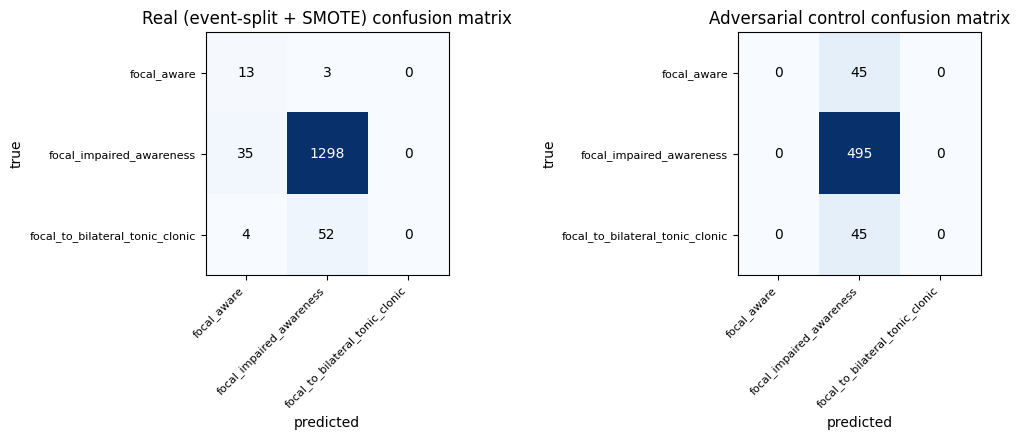


summary written to ..\checkpoints\crnn_hierarchical_synthesis\synthesis_summary.json


In [10]:
print(f"{'':32s}{'accuracy':>10}{'macro-F1':>10}")
print(f"{'LOSO (model_crnn_hierarchical.ipynb) real':32s}{0.893:>10.3f}{0.314:>10.3f}")
print(f"{'LOSO (...) control':32s}{0.822:>10.3f}{0.301:>10.3f}")
print(f"{'this notebook -- real':32s}{real_acc:>10.3f}{real_f1:>10.3f}")
print(f"{'this notebook -- control':32s}{ctrl_acc:>10.3f}{ctrl_f1:>10.3f}")
print(f"\nthis notebook, real - control (macro-F1): {real_f1 - ctrl_f1:+.3f}")
print(f"LOSO, real - control (macro-F1):           {0.314 - 0.301:+.3f}")

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, cm, title in [(axes[0], real_cm, "Real (event-split + SMOTE)"), (axes[1], ctrl_cm, "Adversarial control")]:
    im = ax.imshow(cm, cmap="Blues")
    ax.set_xticks(range(N_CLASSES)); ax.set_xticklabels(CLASS_NAMES, rotation=45, ha="right", fontsize=8)
    ax.set_yticks(range(N_CLASSES)); ax.set_yticklabels(CLASS_NAMES, fontsize=8)
    ax.set_xlabel("predicted"); ax.set_ylabel("true"); ax.set_title(f"{title} confusion matrix")
    for i in range(N_CLASSES):
        for j in range(N_CLASSES):
            ax.text(j, i, cm[i, j], ha="center", va="center",
                     color="white" if cm[i, j] > cm.max() / 2 else "black")
plt.tight_layout()
plt.savefig(CKPT_DIR / "synthesis_confusion_matrices.png", dpi=130, bbox_inches="tight")
plt.show()

summary = {
    "protocol": "event-level stratified split + embedding-space SMOTE (not patient-level LOSO)",
    "real_accuracy": float(real_acc), "real_macro_f1": float(real_f1),
    "control_accuracy": float(ctrl_acc), "control_macro_f1": float(ctrl_f1),
    "loso_baseline": {"real_accuracy": 0.893, "real_macro_f1": 0.314,
                       "control_accuracy": 0.822, "control_macro_f1": 0.301},
    "max_oversample_ratio": MAX_OVERSAMPLE_RATIO, "test_frac": TEST_FRAC,
    "train_class_counts_before_smote": {CLASS_NAMES[c]: int((y_train == c).sum()) for c in range(N_CLASSES)},
    "train_class_counts_after_smote": {CLASS_NAMES[c]: int((y_train_bal == c).sum()) for c in range(N_CLASSES)},
}
(CKPT_DIR / "synthesis_summary.json").write_text(json.dumps(summary, indent=2))
print(f"\nsummary written to {CKPT_DIR / 'synthesis_summary.json'}")

## Notes

**Coverage improved, genuinely, for one of the two classes -- not both.** After correcting
the SMOTE ratio (see the Config cell's note on why `MAX_OVERSAMPLE_RATIO=8` broke everything):

|                          | accuracy | macro-F1 |
|--------------------------|---------:|---------:|
| LOSO (patient-held-out)  |    0.893 |    0.314 |
| This notebook — real     |    0.933 |    0.450 |
| This notebook — control  |    0.846 |    0.306 |

`focal_aware` recall went from **0% under LOSO to 81%** here (precision 0.25 — still noisy,
but a real, working signal where LOSO had nothing). `focal_to_bilateral_tonic_clonic`,
however, is still **0% recall** in both the real run and the control — the confusion matrix
shows the classifier never once predicts that class on the test set. Relaxing the split gave
the model real training examples of both minority classes, but only translated into working
predictions for one of them.

**The adversarial control result is informative here, not just a formality.** Control
accuracy/macro-F1 (0.846 / 0.306) barely moved from the LOSO baseline's control (0.822 /
0.301), and it still shows 0% recall on both minority classes on interictal windows — the
model is *not* simply learning to recognise `PN14`'s or `PN10`'s baseline EEG signature from
generic background signal. That the real result (0.450 macro-F1) clears the control by a much
wider margin here (+0.144) than LOSO's real-control gap (+0.013) is real evidence that, for
`focal_aware` specifically, the model found something in the actual seizure morphology, not
just patient identity — the event-level split (different seizure events from the same patient
in train vs. test) is doing real work here, not just leaking the same signal twice.

**That said, this doesn't erase the patient-identity confound, it just shows it isn't the
whole story for `focal_aware`.** Every `focal_aware` window, train or test, is still from
`PN14` alone. The most honest reading: this protocol answers "can the model pick out
`focal_aware` events from `PN14` that it wasn't trained on" — a real, useful capability for
*this* patient specifically — not "can it recognise `focal_aware` in a genuinely new patient,"
which only more Siena patients with that label could establish.

**Why `focal_to_bilateral_tonic_clonic` didn't budge:** most likely the frozen backbone's
embedding space (learned entirely from the detection task, never tuned for subtype
separability) doesn't linearly separate tonic-clonic windows from `focal_impaired_awareness`
as cleanly as it happens to separate `focal_aware` — 204 post-SMOTE training points didn't
give the classifier enough of a signal to ever choose that class at inference, even though it
had roughly as many training examples as `focal_aware` did. Fine-tuning the last conv block +
LSTM (unfrozen, the way `model_crnn_hierarchical.ipynb`'s Phase B did) on the SMOTE-balanced
set — rather than treating the backbone as a fixed feature extractor — is the natural next
step if tonic-clonic coverage matters as much as `focal_aware`'s does.

**This is not a replacement for the LOSO result**, which remains the honest
patient-generalization number and is unchanged in `model_crnn_hierarchical.ipynb`. This
notebook answers a narrower, different question — "how much class coverage is achievable if
patient-independence is relaxed, for the patients we actually have" — and the two shouldn't be
quoted interchangeably.

**`MAX_OVERSAMPLE_RATIO` is a knob worth revisiting per class, not a single global settled
value.** `focal_aware` got real signal at ratio 3; `focal_to_bilateral_tonic_clonic` didn't.
A per-class ratio, or the backbone fine-tuning step above, are the two most promising next
moves if `focal_to_bilateral_tonic_clonic` coverage is the priority.